# Multi-Game Visualization and Basketball Insights

## Objective

This notebook transforms the reconstructed multi-game lineup and player metrics into visual analytics and interpretable basketball insights.

The goal is to:

- visualize player impact distributions
- identify high-performing lineups
- explore player synergy relationships
- evaluate modeling behavior
- generate dashboard-ready visual outputs

## Why this matters

Visualization bridges the gap between analytics pipelines and basketball decision-making.

These charts help translate lineup reconstruction, player impact metrics, and predictive modeling results into interpretable information for coaches, analysts, and stakeholders.

In [26]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", 200)

## Load processed analytics datasets

In [27]:
player_impact = pd.read_csv("../data/processed/reliable_player_impact.csv")
lineup_perf = pd.read_csv("../data/processed/reliable_lineups.csv")
pair_perf = pd.read_csv("../data/processed/reliable_pair_performance.csv")

model_results = pd.read_csv("../data/processed/model_results.csv")
feature_importance = pd.read_csv("../data/processed/model_feature_importance.csv")

player_impact.shape, lineup_perf.shape, pair_perf.shape

((363, 6), (3267, 8), (1618, 6))

## Build player name lookup

Player identifiers are converted into readable player names to improve visualization clarity and dashboard usability.

In [28]:
stints_raw = pd.read_pickle(
    "../data/interim/stints_multigame_validated.pkl"
)

player_name_records = []

for _, row in stints_raw.iterrows():

    # Home lineup names
    if "home_lineup_names" in row:
        for pid, pname in zip(
            row["home_lineup"],
            row["home_lineup_names"]
        ):
            player_name_records.append({
                "player_id": str(pid),
                "player_name": pname
            })

    # Away lineup names
    if "away_lineup_names" in row:
        for pid, pname in zip(
            row["away_lineup"],
            row["away_lineup_names"]
        ):
            player_name_records.append({
                "player_id": str(pid),
                "player_name": pname
            })

player_name_df = (
    pd.DataFrame(player_name_records)
    .drop_duplicates()
)

player_name_lookup = dict(
    zip(
        player_name_df["player_id"],
        player_name_df["player_name"]
    )
)

len(player_name_lookup)

383

## Player impact distribution

We examine how player impact values are distributed across the multi-game sample.

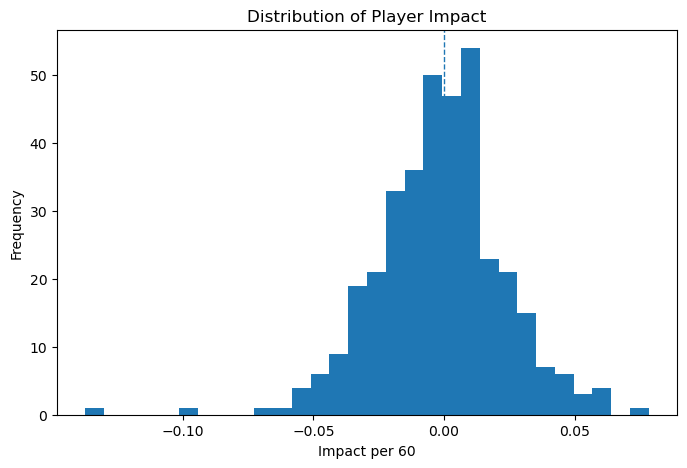

In [29]:
plt.figure(figsize=(8, 5))

plt.hist(
    player_impact["impact_per_60_sec"],
    bins=30
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Impact per 60")
plt.ylabel("Frequency")
plt.title("Distribution of Player Impact")

plt.show()

## Top player impact performers

In [30]:
top_players = (
    player_impact
    .sort_values("impact_per_60_sec", ascending=False)
    .head(15)
    .copy()
)

top_players["player_name"] = (
    top_players["player_id"]
    .astype(str)
    .map(player_name_lookup)
)

top_players

,player_id,total_net_points,total_duration,total_stints,impact_per_60_sec,stints_per_game,player_name
281,693,34,434,36,0.078341,NaN,Joe Smith
265,56,101,1589,102,0.063562,NaN,Gary Payton
162,2045,50,849,70,0.058893,NaN,Hedo Turkoglu
168,2054,17,294,22,0.057823,NaN,Jake Tsakalidis
209,280,26,454,31,0.057269,NaN,Felton Spencer
333,935,28,501,43,0.055888,NaN,Bryon Russell
295,722,139,2536,153,0.054811,NaN,Corliss Williamson
196,239,12,228,13,0.052632,NaN,Darrick Martin
274,682,37,773,57,0.047865,NaN,Bob Sura
307,764,29,621,45,0.046699,NaN,David Robinson


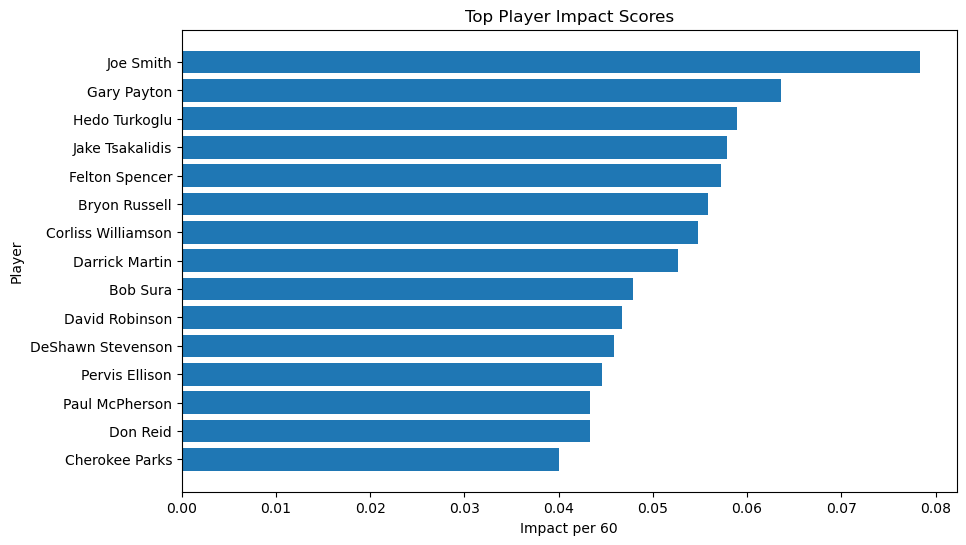

In [31]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_players["player_name"],
    top_players["impact_per_60_sec"]
)

plt.xlabel("Impact per 60")
plt.ylabel("Player")
plt.title("Top Player Impact Scores")

plt.gca().invert_yaxis()

plt.show()

## Lineup performance distribution

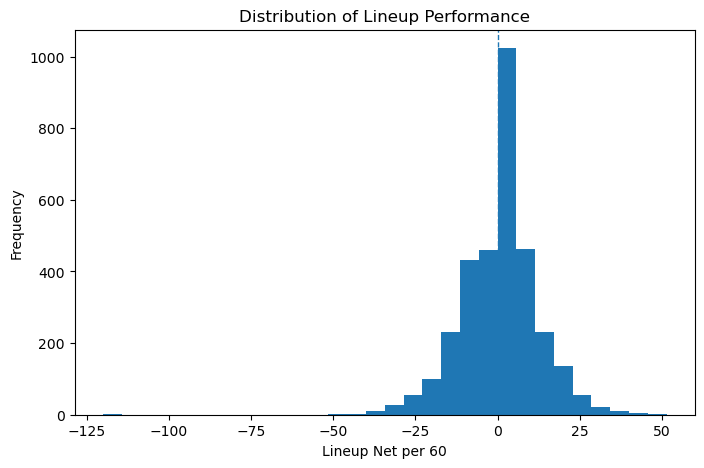

In [32]:
plt.figure(figsize=(8, 5))

plt.hist(
    lineup_perf["net_per_60"],
    bins=30
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Lineup Net per 60")
plt.ylabel("Frequency")
plt.title("Distribution of Lineup Performance")

plt.show()

## Highest-performing lineups

In [33]:
top_lineups = (
    lineup_perf
    .sort_values(
        ["net_per_60", "total_duration"],
        ascending=[False, False]
    )
    .head(10)
)

top_lineups[[
    "home_lineup_tuple",
    "net_per_60",
    "total_duration",
    "total_stints"
]]

,home_lineup_tuple,net_per_60,total_duration,total_stints
2664,"('1717', '363', '458', '919', '93')",51.428571,7,1
1333,"('1499', '1559', '179', '2040', '677')",50.000000,6,1
2971,"('1890', '201', '2091', '2092', '2101')",48.000000,5,1
2988,"('1890', '201', '2092', '2101', '915')",42.857143,7,1
2659,"('1717', '363', '458', '714', '762')",40.000000,12,1
466,"('109', '216', '296', '323', '977')",40.000000,6,1
2454,"('1709', '1838', '1885', '399', '976')",40.000000,6,1
2994,"('1890', '201', '2101', '361', '916')",40.000000,6,1
2973,"('1890', '201', '2091', '361', '467')",37.894737,19,1
2547,"('1713', '213', '349', '722', '891')",37.674419,43,1


## Player pair synergy distribution

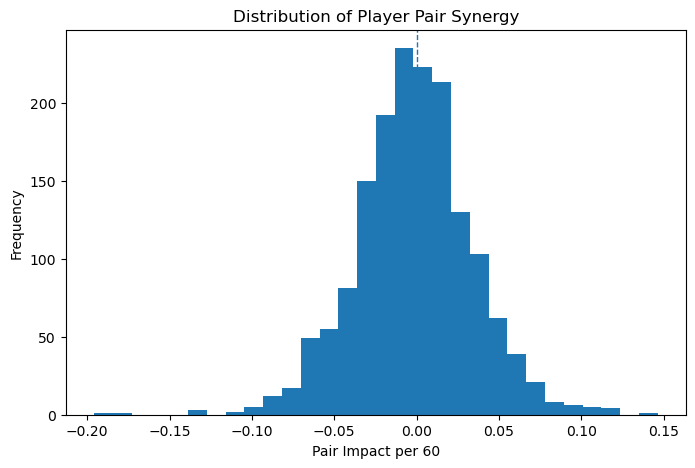

In [34]:
plt.figure(figsize=(8, 5))

plt.hist(
    pair_perf["impact_per_60"],
    bins=30
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Pair Impact per 60")
plt.ylabel("Frequency")
plt.title("Distribution of Player Pair Synergy")

plt.show()

## Strongest player pair synergies

In [35]:
top_pairs = (
    pair_perf
    .sort_values(
        ["impact_per_60", "total_duration"],
        ascending=[False, False]
    )
    .head(15)
)

top_pairs["player_1_name"] = (
    top_pairs["player_1"]
    .astype(str)
    .map(player_name_lookup)
)

top_pairs["player_2_name"] = (
    top_pairs["player_2"]
    .astype(str)
    .map(player_name_lookup)
)

top_pairs[[
    "player_1_name",
    "player_2_name",
    "impact_per_60",
    "total_duration"
]]

,player_1_name,player_2_name,impact_per_60,total_duration
1363,Felton Spencer,Kurt Thomas,0.146341,205
949,Wally Szczerbiak,Sam Mitchell,0.122807,285
28,Emanual Davis,Gary Payton,0.122677,269
168,Patrick Ewing,Gary Payton,0.113269,927
1413,Mark Jackson,Tyrone Corbin,0.112500,240
922,Baron Davis,Lee Nailon,0.108696,322
1345,Allan Houston,Felton Spencer,0.106762,281
1467,Monty Williams,Don Reid,0.103448,232
265,Jud Buechler,Joe Smith,0.102881,243
1574,Corliss Williamson,Charles Oakley,0.101237,889


## Model performance comparison

In [36]:
model_results

,model,rmse,mae,r2
0,Linear Regression,6.899536,5.466027,0.042369
1,Ridge Regression,6.981226,5.517249,0.019558
2,Random Forest,6.949774,5.475943,0.028372


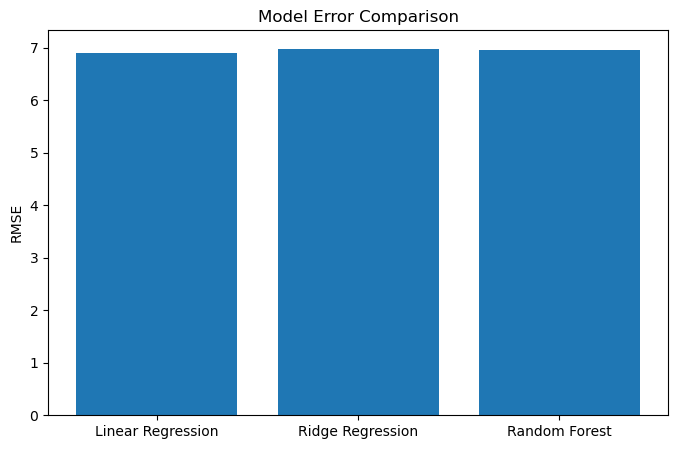

In [37]:
plt.figure(figsize=(8, 5))

plt.bar(
    model_results["model"],
    model_results["rmse"]
)

plt.ylabel("RMSE")
plt.title("Model Error Comparison")

plt.show()

## Feature importance analysis

Feature importance helps explain which variables contribute most to lineup performance prediction.

In [38]:
feature_importance.head(15)

,feature,coefficient
0,away_std_player_impact,247.269642
1,away_min_player_impact,71.446813
2,star_gap,61.907981
3,max_impact_diff,61.907981
4,std_player_impact,33.188864
5,min_player_impact,25.191585
6,max_player_impact,11.894474
7,away_avg_player_impact,1.967531
8,total_duration,-0.004150
9,total_stints,-0.008993


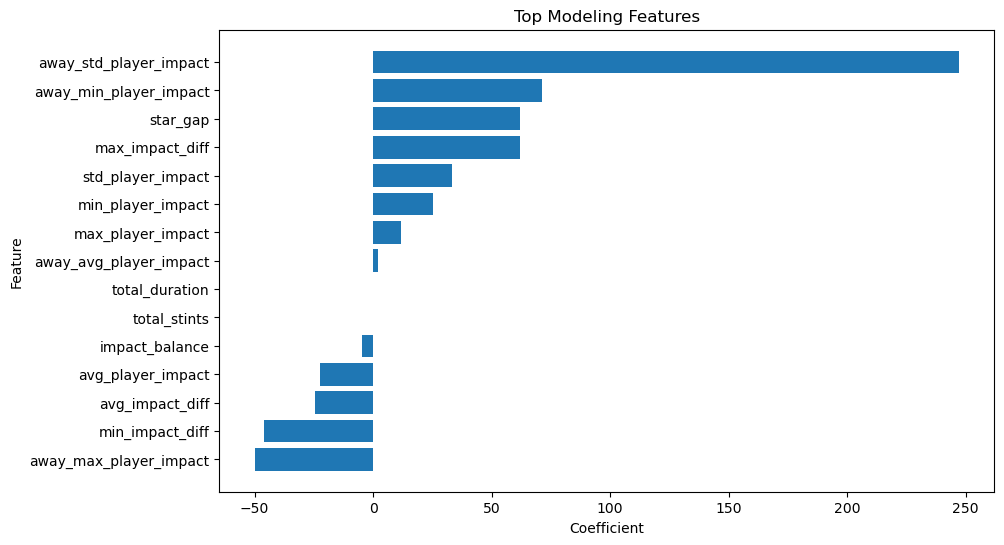

In [39]:
if "importance" in feature_importance.columns:

    top_features = (
        feature_importance
        .sort_values("importance", ascending=False)
        .head(15)
    )

    value_col = "importance"

else:

    top_features = (
        feature_importance
        .sort_values("coefficient", ascending=False)
        .head(15)
    )

    value_col = "coefficient"


plt.figure(figsize=(10, 6))

plt.barh(
    top_features["feature"],
    top_features[value_col]
)

plt.xlabel(value_col.capitalize())
plt.ylabel("Feature")
plt.title("Top Modeling Features")

plt.gca().invert_yaxis()

plt.show()

## Feature correlation analysis

In [40]:
correlation_df = player_impact[[
    "total_net_points",
    "total_duration",
    "total_stints",
    "impact_per_60_sec"
]]

correlation_df.corr()

,total_net_points,total_duration,total_stints,impact_per_60_sec
total_net_points,1.000000,0.128674,0.095167,0.754211
total_duration,0.128674,1.000000,0.986424,0.114652
total_stints,0.095167,0.986424,1.000000,0.096659
impact_per_60_sec,0.754211,0.114652,0.096659,1.000000


## Modeling interpretation

The visual analysis shows that lineup performance and player impact contain measurable structure, although substantial variability remains across games and lineup combinations.

Player impact distributions remain centered near zero, while high-performing lineups and player pairs appear as smaller subsets with stronger positive scoring outcomes.

The modeling results indicate that player-impact-derived features and lineup differential features contribute useful predictive signal, although basketball lineup performance remains inherently noisy due to opponent effects, rotation changes, and contextual variability.

These findings support the use of the reconstructed multi-game dataset as a foundation for scalable basketball analytics workflows.

## Save dashboard-ready datasets

In [41]:
top_players.to_csv(
    "../data/processed/dashboard_top_players.csv",
    index=False
)

top_lineups.to_csv(
    "../data/processed/dashboard_top_lineups.csv",
    index=False
)

top_pairs.to_csv(
    "../data/processed/dashboard_top_pairs.csv",
    index=False
)

print("Dashboard-ready datasets saved successfully.")

Dashboard-ready datasets saved successfully.


## Key findings

The visualization layer highlights how reconstructed lineup data can be translated into interpretable basketball insights.

Key outcomes:

- Player impact distributions reveal both stable contributors and high-variance performers
- Lineup-level metrics identify productive lineup combinations
- Player pair synergy analysis captures interaction effects between teammates
- Predictive modeling demonstrates measurable lineup-performance signal
- Feature importance analysis helps explain the drivers behind lineup outcomes

## Conclusion

The project now includes:

- scalable multi-game lineup reconstruction
- validation workflows
- performance metrics
- predictive modeling
- visualization and storytelling layers

Together, these components form a complete basketball analytics pipeline capable of supporting future dashboard development and expanded modeling efforts.